# 05 · Análisis de errores e interpretación (T-09)

**Dónde:** `pipeline/src/ml/errores.py`. **Por qué:** una métrica sola no dice dónde ni por qué falla el modelo.
**Cómo:** curva de umbral, calibración por decil y perfil de aciertos y errores en la prueba temporal.
**Con qué datos:** las predicciones del modelo elegido en T-07 sobre los 4 últimos periodos etiquetados.

In [1]:
import sys, pathlib
raiz = pathlib.Path.cwd()
while not (raiz / "pipeline").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 120)
from pipeline.notebooks.graficas import dibujar, tabla

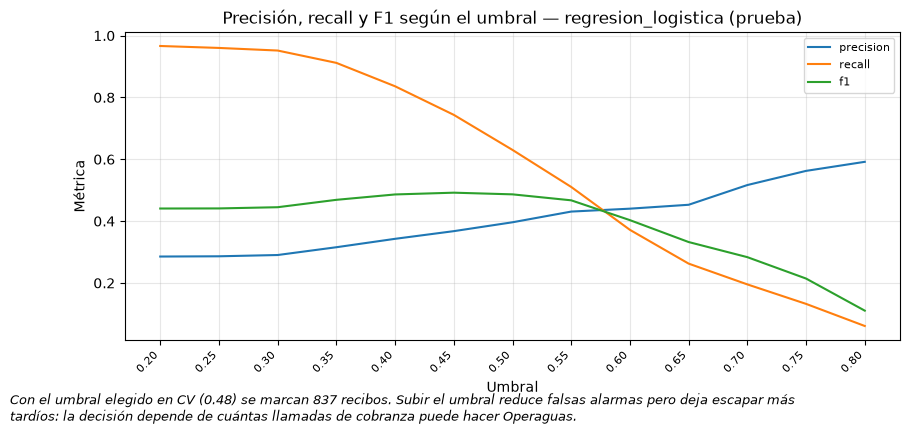

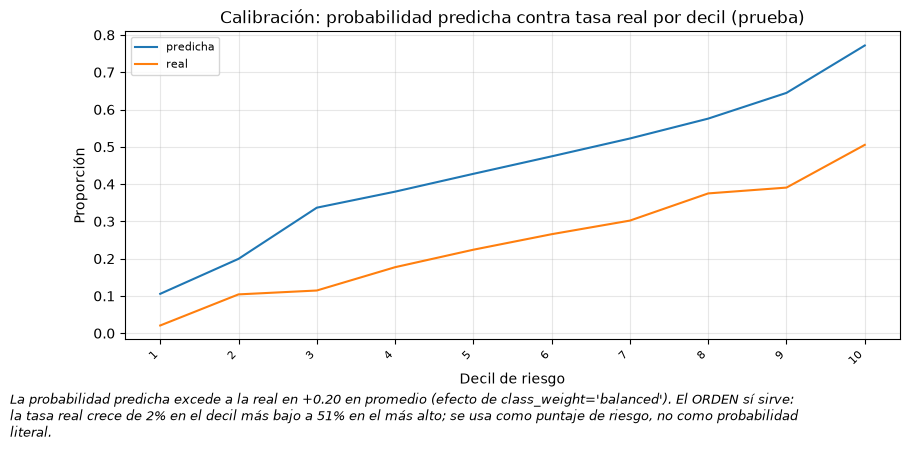

**Perfil de aciertos y errores (promedios en prueba)**

,grupo,n,domiciliado,tasa_tardio_historica,tardio_anterior,total_pagar,medidor_mudo
0,a tiempo correcto,928,0.334,0.119,0.069,1092.242,0.045
1,falsa alarma,516,0.002,0.391,0.413,1856.438,0.054
2,tardío NO detectado,155,0.161,0.190,0.187,1235.667,0.039
3,tardío detectado,321,0.000,0.426,0.536,1971.349,0.069


_Los tardíos no detectados tienen historial de atraso de 19% contra 43% de los detectados: el modelo falla con quien casi nunca se atrasaba (atrasos 'nuevos'), algo que ninguna variable disponible al emitir el recibo anticipa._  
`fuente: pipeline/src/ml/errores.py · pipeline/notebooks/05_errores.ipynb`

In [2]:
from pipeline.src.ml import errores
salida = errores.ejecutar()
for r in salida:
    dibujar(r["payload"])

## Conclusiones

In [3]:
for r in salida:
    print(f"- {r['payload']['titulo']}: {r['payload']['conclusion']}")

- Precisión, recall y F1 según el umbral — regresion_logistica (prueba): Con el umbral elegido en CV (0.48) se marcan 837 recibos. Subir el umbral reduce falsas alarmas pero deja escapar más tardíos: la decisión depende de cuántas llamadas de cobranza puede hacer Operaguas.
- Calibración: probabilidad predicha contra tasa real por decil (prueba): La probabilidad predicha excede a la real en +0.20 en promedio (efecto de class_weight='balanced'). El ORDEN sí sirve: la tasa real crece de 2% en el decil más bajo a 51% en el más alto; se usa como puntaje de riesgo, no como probabilidad literal.
- Perfil de aciertos y errores (promedios en prueba): Los tardíos no detectados tienen historial de atraso de 19% contra 43% de los detectados: el modelo falla con quien casi nunca se atrasaba (atrasos 'nuevos'), algo que ninguna variable disponible al emitir el recibo anticipa.
